In [123]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [124]:
df=pd.read_csv("/Users/priyanshukumar/Desktop/Advance_Coding/Project_1/CIRC_model_ready.csv")
print(df.shape)
df.isnull().sum()
df.head()

(1141, 14)


,D,t,Fy,fc,L,Dt,LD,Ac,As,SteelCap,ConcCap,Squash,Xi,Pexp
0,94.996,12.4968,274.618291,27.365302,1420.114,7.601626,14.949198,3848.714899,3238.906636,889.463004,105.321247,994.784252,8.445238,947.026382
1,94.996,12.7508,272.618810,27.365302,1420.114,7.450199,14.949198,3793.058149,3294.563385,898.159951,103.798183,1001.958134,8.652945,937.685116
2,94.996,12.3952,272.618810,27.365302,1420.114,7.663934,14.949198,3871.091101,3216.530433,876.886700,105.933579,982.820279,8.277703,906.992387
3,94.996,12.5984,274.618291,27.365302,860.044,7.540323,9.053476,3826.403555,3261.217979,895.590107,104.710691,1000.300798,8.552996,1017.753106
4,94.996,12.7000,272.618810,27.365302,860.044,7.480000,9.053476,3804.157070,3283.464465,895.134176,104.101909,999.236085,8.598634,1007.967018


### Transforming Data

In [125]:
x=df.drop("Pexp",axis=1)
y=df["Pexp"]

In [126]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

### Data Preprocessing

In [127]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [128]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

### 2nd Best Model

                    Model  R2 Score   RMSE     MAE  MAPE (%)
XGBoost (L2) Testing Data    0.9788 586.57 217.286     14.36
                     Model  R2 Score    RMSE    MAE  MAPE (%)
XGBoost (L2) Training Data    0.9989 170.384 89.425      9.39


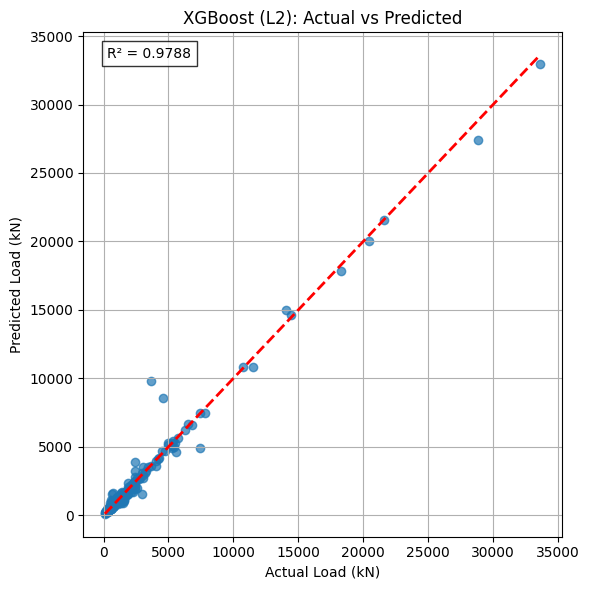

In [129]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(x_train_scaled, y_train)

# Prediction
y_xgb_train = xgb_model.predict(x_train_scaled)
y_xgb_pred = xgb_model.predict(x_test_scaled)

# Evaluation
xgb_results = pd.DataFrame({
    "Model": ["XGBoost (L2) Testing Data"],
    "R2 Score": [round(r2_score(y_test, y_xgb_pred),4)],
    "RMSE": [round(root_mean_squared_error(y_test, y_xgb_pred),3)],
    "MAE": [round(mean_absolute_error(y_test, y_xgb_pred),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_test, y_xgb_pred)*100,2)]
})
print(xgb_results.to_string(index=False))

xgb_res_train = pd.DataFrame({
    "Model": ["XGBoost (L2) Training Data"],
    "R2 Score": [round(r2_score(y_train, y_xgb_train),4)],
    "RMSE": [round(root_mean_squared_error(y_train, y_xgb_train),3)],
    "MAE": [round(mean_absolute_error(y_train, y_xgb_train),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_train, y_xgb_train)*100,2)]
})
print(xgb_res_train.to_string(index=False))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_xgb_pred, alpha=0.7)

min_val = min(y_test.min(), y_xgb_pred.min())
max_val = max(y_test.max(), y_xgb_pred.max())

plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title("XGBoost (L2): Actual vs Predicted")

plt.text(
    0.05,0.95,
    f"R² = {r2_score(y_test,y_xgb_pred):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white",alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()

## Best Model - CatBoost L2

                     Model  R2 Score    RMSE     MAE  MAPE (%)
CatBoost (L2) Testing Data    0.9813 551.642 210.081     13.85
                      Model  R2 Score    RMSE    MAE  MAPE (%)
CatBoost (L2 Training Data)    0.9989 170.745 90.034      9.05


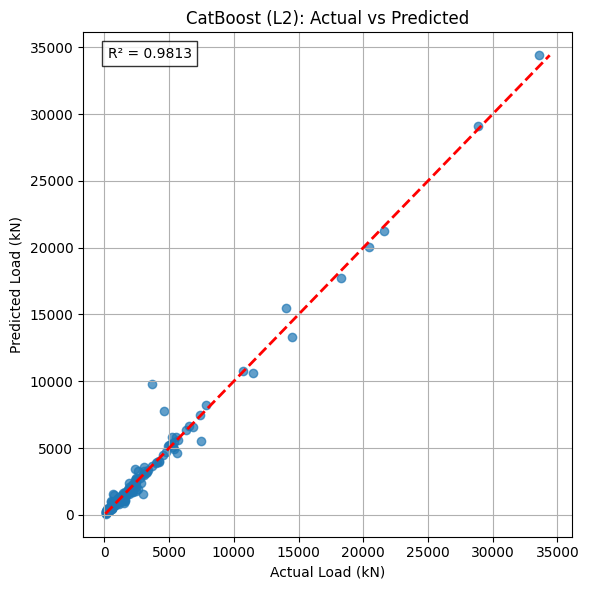

In [135]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=1200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat_model.fit(x_train_scaled, y_train)

# Prediction
y_cat_train = cat_model.predict(x_train_scaled)
y_cat_pred = cat_model.predict(x_test_scaled)

# Evaluation
cat_results = pd.DataFrame({
    "Model": ["CatBoost (L2) Testing Data"],
    "R2 Score": [round(r2_score(y_test, y_cat_pred),4)],
    "RMSE": [round(root_mean_squared_error(y_test, y_cat_pred),3)],
    "MAE": [round(mean_absolute_error(y_test, y_cat_pred),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_test, y_cat_pred)*100,2)]
})
print(cat_results.to_string(index=False))

cat_res_train = pd.DataFrame({
    "Model": ["CatBoost (L2 Training Data)"],
    "R2 Score": [round(r2_score(y_train, y_cat_train),4)],
    "RMSE": [round(root_mean_squared_error(y_train, y_cat_train),3)],
    "MAE": [round(mean_absolute_error(y_train, y_cat_train),3)],
    "MAPE (%)": [round(mean_absolute_percentage_error(y_train, y_cat_train)*100,2)]
})
print(cat_res_train.to_string(index=False))

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_cat_pred, alpha=0.7)

min_val = min(y_test.min(), y_cat_pred.min())
max_val = max(y_test.max(), y_cat_pred.max())

plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2)

plt.xlabel("Actual Load (kN)")
plt.ylabel("Predicted Load (kN)")
plt.title("CatBoost (L2): Actual vs Predicted")

plt.text(
    0.05,0.95,
    f"R² = {r2_score(y_test,y_cat_pred):.4f}",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor="white",alpha=0.8)
)

plt.grid(True)
plt.tight_layout()
plt.show()
